In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import math
from scipy.stats import pearsonr

In [4]:
df = pd.read_csv("Final Data Integration.xls")
print(df['duration_seconds'].max())
df.head()


57468


,url,title,category,duration_seconds,view_count,like_count,comment_count
0,https://www.youtube.com/watch?v=zuiU_mD-p0c,This ONE Bible Verse Boosted My Faith #Shorts,religious content,55,1097261,165069,45568
1,https://www.youtube.com/watch?v=ztFAl1To3Wo,Ever tried Crispy Banana Bonda 🤤#shorts,food recipes,52,95273478,1468403,6862
2,https://www.youtube.com/watch?v=zpQ_jC57W4E,Camera Flash tip for beginners - Godox v1 lamp...,photography tutorials,23,479077,9712,92
3,https://www.youtube.com/watch?v=zlomFl0KSVQ,Extend Background Photo - Short Photoshop Tuto...,photography tutorials,31,198509,7118,24
4,https://www.youtube.com/watch?v=zcTCJCLCKEA,Grand Celebration of the Twins with Special Pe...,vlogs,838,4989,238,17


In [5]:
df['likes_per_view'] = df['like_count'] / df['view_count']
df['comments_per_view'] = df['comment_count'] / df['view_count']
df['duration_seconds'].max()

57468

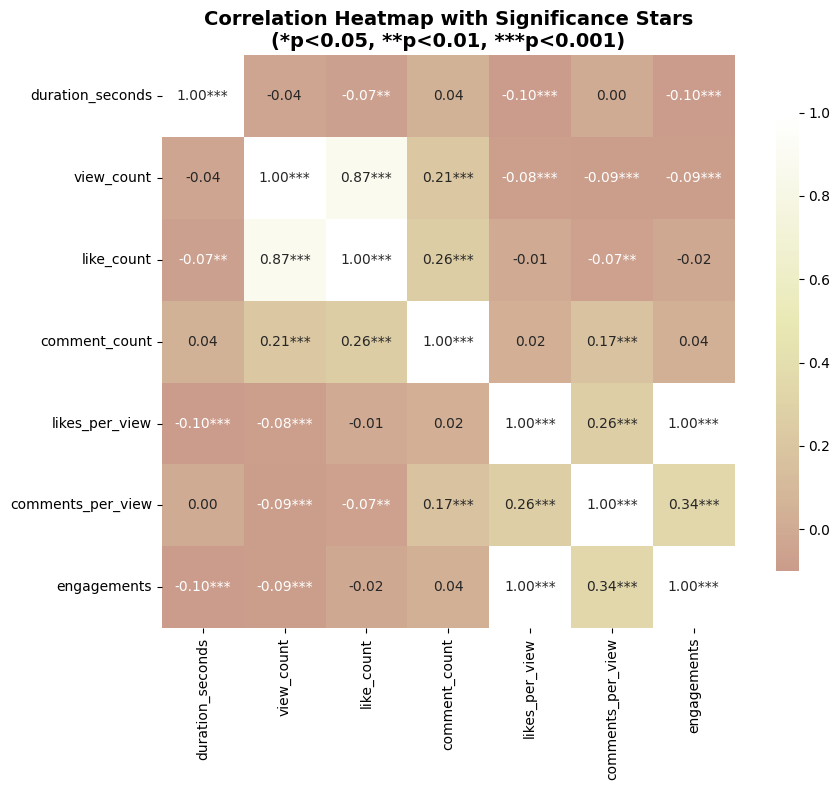

In [6]:
# Create engagements column
df['engagements'] = df['likes_per_view'] + df['comments_per_view']

# Select numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

# Function to add significance stars
def add_significance_stars(corr_matrix, df, numeric_cols):
    """Add significance stars to correlation values"""
    n = len(df)
    annot_matrix = corr_matrix.copy().astype(str)
    
    for i, col1 in enumerate(numeric_cols):
        for j, col2 in enumerate(numeric_cols):
            if i <= j:  # Upper triangle
                corr, p_value = pearsonr(df[col1], df[col2])
                stars = ''
                if p_value < 0.001:
                    stars = '***'
                elif p_value < 0.01:
                    stars = '**'
                elif p_value < 0.05:
                    stars = '*'
                
                annot_matrix.iloc[i, j] = f"{corr:.2f}{stars}"
                annot_matrix.iloc[j, i] = f"{corr:.2f}{stars}"
    
    return annot_matrix

# Create annotation matrix with stars
annot_matrix = add_significance_stars(corr_matrix, df, numeric_cols)

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, 
            annot=annot_matrix.values,  # Use our annotated values
            cmap='pink',
            center=0,
            fmt='',  # No formatting since we provide formatted strings
            square=True,
            cbar_kws={'shrink': 0.8})

plt.title('Correlation Heatmap with Significance Stars\n(*p<0.05, **p<0.01, ***p<0.001)', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

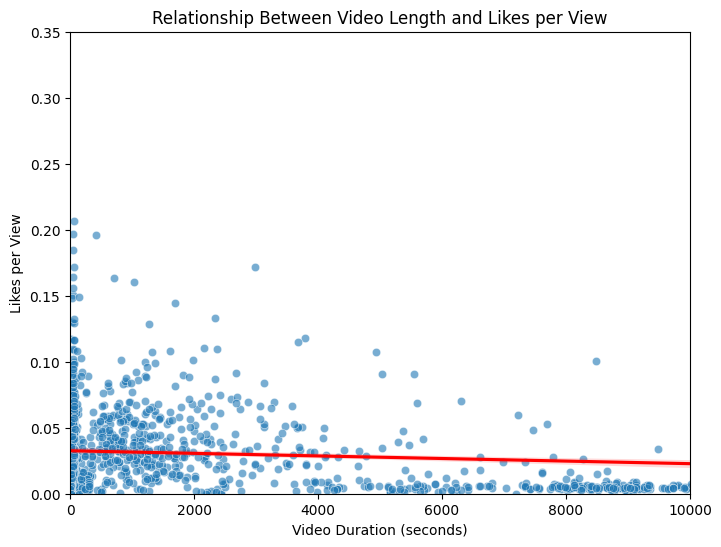

In [7]:
plt.figure(figsize=(8,6))

# Scatter plot
sns.scatterplot(data=df, x='duration_seconds', y='likes_per_view', alpha=0.6)

# Trend line
sns.regplot(data=df, x='duration_seconds', y='likes_per_view', scatter=False, color='red')

# Axis labels and title
plt.xlabel("Video Duration (seconds)")
plt.ylabel("Likes per View")
plt.title("Relationship Between Video Length and Likes per View")

# Limit y-axis to 0 - 0.5
plt.ylim(0, 0.35)
plt.xlim(0, 10000)

plt.show()

In [8]:
print(df['view_count'].mean())
print(df['duration_seconds'].mean())
print(df['likes_per_view'].mean())
print(df['comments_per_view'].mean())

13151321.957660167
1865.2200557103065
0.030721912224569676
0.0013891529949496073


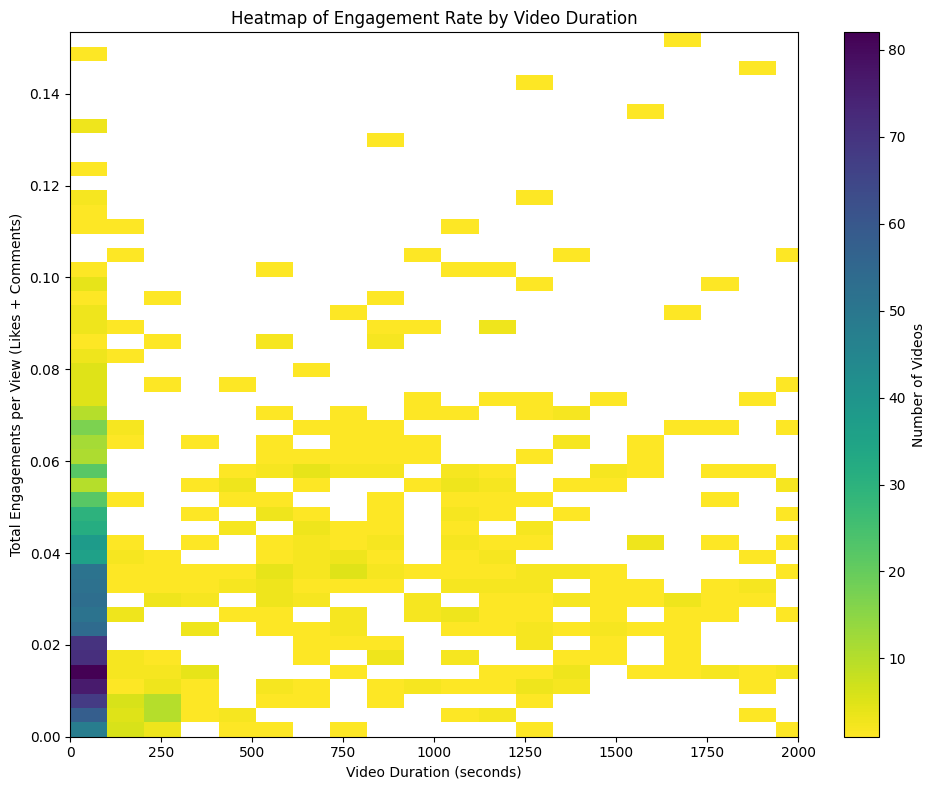

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Create engagements column
df['engagements'] = df['likes_per_view'] + df['comments_per_view']

plt.figure(figsize=(10, 8))

# LINEAR bins for duration (seconds)
bins_x = np.linspace(0, 5000, 50)

# LINEAR bins for engagement (clip outliers)
max_engagement = min(df['engagements'].quantile(0.99), 0.3)
bins_y = np.linspace(0, max_engagement, 50)

# 2D histogram heatmap
plt.hist2d(
    df['duration_seconds'],
    df['engagements'],
    bins=[bins_x, bins_y],
    cmap='viridis_r',
    cmin=1
)

# Colorbar
plt.colorbar(label='Number of Videos')

# Labels (LINEAR, TRUE UNITS)
plt.xlabel('Video Duration (seconds)')
plt.ylabel('Total Engagements per View (Likes + Comments)')
plt.title('Heatmap of Engagement Rate by Video Duration')

plt.xlim(0, 2000)
plt.ylim(0, max_engagement)

plt.tight_layout()
plt.show()


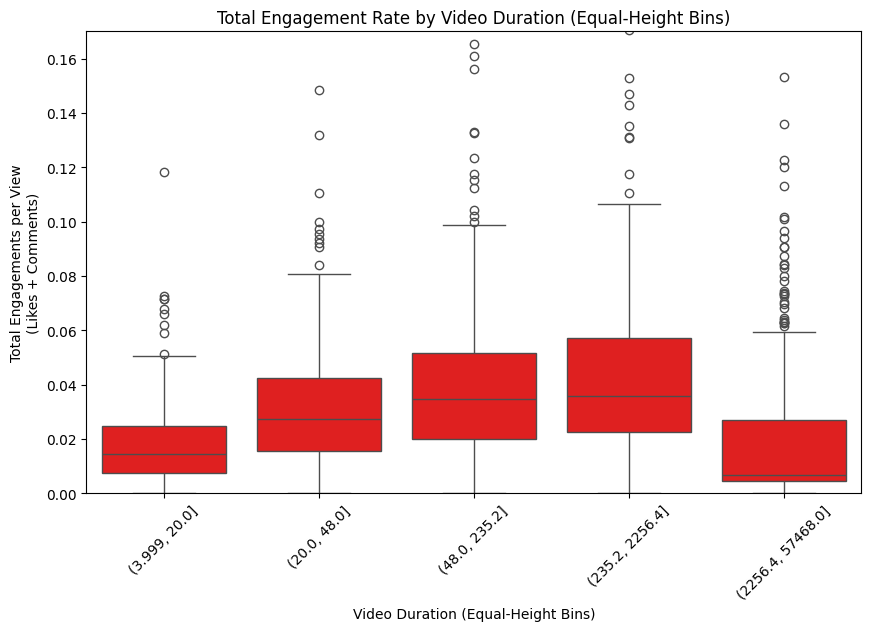

In [10]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create engagements column if not already done
df['engagements'] = df['likes_per_view'] + df['comments_per_view']

# Create duration bins using quantiles
num_quantiles = 5
df['duration_bin_quantile'] = pd.qcut(df['duration_seconds'], q=num_quantiles)

plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='duration_bin_quantile', y='engagements', color="red")
plt.xticks(rotation=45)
plt.xlabel("Video Duration (Equal-Height Bins)")
plt.ylabel("Total Engagements per View\n(Likes + Comments)")

plt.title("Total Engagement Rate by Video Duration (Equal-Height Bins)")
plt.ylim(0, 0.170)  # Adjusted for combined engagements
plt.show()

In [11]:
import numpy as np
from scipy import stats

# Define groups (short < 900s, long >= 900s)
short_videos = df[df['duration_seconds'] < 900]
long_videos  = df[df['duration_seconds'] >= 900]

metrics = ['likes_per_view', 'comments_per_view']

for metric in metrics:
    group1 = short_videos[metric].values
    group2 = long_videos[metric].values
    
    mean1 = np.mean(group1)
    mean2 = np.mean(group2)
    diff = mean1 - mean2
    
    t_stat, p_value = stats.ttest_ind(group1, group2, equal_var=False)
    
    print(f"--- {metric} ---")
    print(f"Mean (short videos): {mean1:.4f}")
    print(f"Mean (long videos):  {mean2:.4f}")
    print(f"Difference (short - long): {diff:.4f}")
    print(f"T-test statistic: {t_stat:.4f}")
    print(f"P-value: {p_value:.4f}\n")


--- likes_per_view ---
Mean (short videos): 0.0324
Mean (long videos):  0.0270
Difference (short - long): 0.0054
T-test statistic: 2.8964
P-value: 0.0038

--- comments_per_view ---
Mean (short videos): 0.0010
Mean (long videos):  0.0023
Difference (short - long): -0.0014
T-test statistic: -6.3550
P-value: 0.0000



In [12]:
import numpy as np

# Option 2: Or use custom thresholds (better for interpretability)
def categorize_duration(seconds):
    if seconds < 120:           # Short: < 1 minute
        return 'short'
    else:                      # Long: > 5 minutes
        return 'long'

df['duration_group'] = df['duration_seconds'].apply(categorize_duration)


In [13]:
import pandas as pd
from scipy.stats import chi2_contingency

# Create engagement category (high/low)
df['comments_engagement_cat'] = ['High' if x >= df['comments_per_view'].median() else 'Low' for x in df['comments_per_view']]

# Crosstab of duration group vs engagement category
contingency_table = pd.crosstab(df['duration_group'], df['comments_engagement_cat'])
# Chi-square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

# Create a table with observed (expected)
combined_table = contingency_table.copy()
for i in contingency_table.index:
    for j in contingency_table.columns:
        combined_table.loc[i, j] = f"{contingency_table.loc[i, j]} ({expected[contingency_table.index.get_loc(i), contingency_table.columns.get_loc(j)]:.2f})"

print("Observed (Expected) Table:\n")
print(combined_table)
print(f"\nChi2 Statistic = {chi2:.3f}, p-value = {p:.4f}")


Observed (Expected) Table:

comments_engagement_cat          High           Low
duration_group                                     
long                     544 (381.21)  218 (380.79)
short                    354 (516.79)  679 (516.21)

Chi2 Statistic = 240.237, p-value = 0.0000


C:\Users\Ahmed\AppData\Local\Temp\ipykernel_2036\1007293037.py:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '544 (381.21)' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  combined_table.loc[i, j] = f"{contingency_table.loc[i, j]} ({expected[contingency_table.index.get_loc(i), contingency_table.columns.get_loc(j)]:.2f})"
C:\Users\Ahmed\AppData\Local\Temp\ipykernel_2036\1007293037.py:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '218 (380.79)' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  combined_table.loc[i, j] = f"{contingency_table.loc[i, j]} ({expected[contingency_table.index.get_loc(i), contingency_table.columns.get_loc(j)]:.2f})"


Regression Equation: engagements = -0.00000098 * duration + 0.033931
Slope: -0.00000098 (engagements per second of duration)
Intercept: 0.033931 (baseline engagement rate at 0 seconds)
R-squared: 0.0095
Correlation coefficient: -0.0974


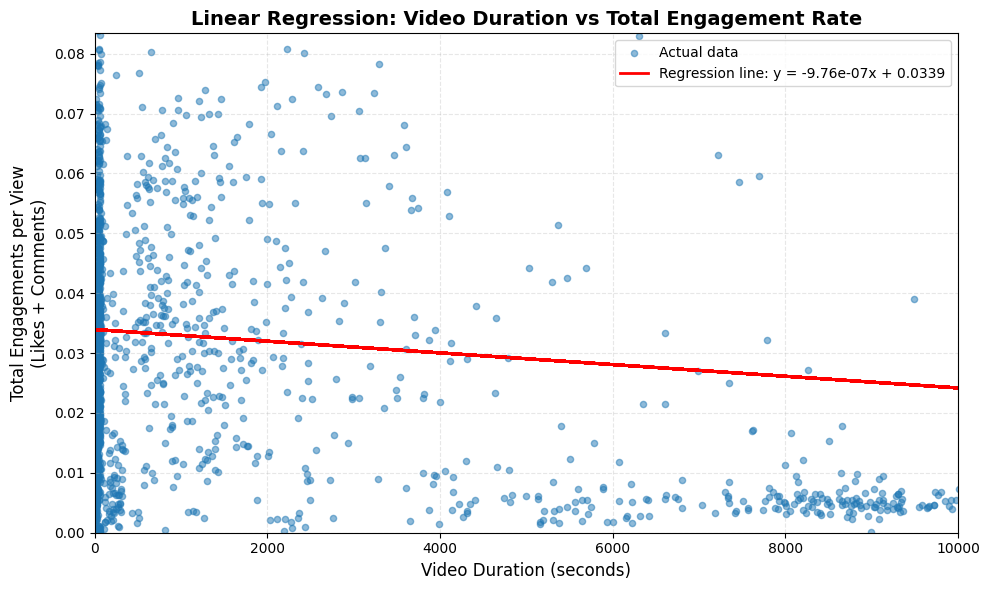


INTERPRETATION:
Negative slope (-9.76e-07): As video duration increases by 1 second, total engagement decreases by 0.000001 per view.
R-squared of 0.0095 means that 0.9% of the variation in engagement can be explained by video duration.


In [14]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import numpy as np

# Create engagements column if not already done
df['engagements'] = df['likes_per_view'] + df['comments_per_view']

# Prepare data for linear regression
X = df[['duration_seconds']]  # Independent variable (needs to be 2D)
y = df['engagements']         # Dependent variable - now using total engagements

# Create linear regression model
model = LinearRegression()
model.fit(X, y)

# Get slope and intercept
slope = model.coef_[0]
intercept = model.intercept_
print(f"Regression Equation: engagements = {slope:.8f} * duration + {intercept:.6f}")
print(f"Slope: {slope:.8f} (engagements per second of duration)")
print(f"Intercept: {intercept:.6f} (baseline engagement rate at 0 seconds)")
print(f"R-squared: {model.score(X, y):.4f}")

# Calculate correlation
correlation = df['duration_seconds'].corr(df['engagements'])
print(f"Correlation coefficient: {correlation:.4f}")

# Predict values for plotting
y_pred = model.predict(X)

# Create the plot
plt.figure(figsize=(10, 6))

# Scatter plot
plt.scatter(X, y, alpha=0.5, s=20, label='Actual data')

# Regression line
plt.plot(X, y_pred, color='red', linewidth=2, 
         label=f'Regression line: y = {slope:.2e}x + {intercept:.4f}')

# Labels and title
plt.xlabel('Video Duration (seconds)', fontsize=12)
plt.ylabel('Total Engagements per View\n(Likes + Comments)', fontsize=12)
plt.title('Linear Regression: Video Duration vs Total Engagement Rate', fontsize=14, fontweight='bold')

# Set limits
plt.xlim(0, 10000)
plt.ylim(0, df['engagements'].quantile(0.95))

# Add grid and legend
plt.grid(alpha=0.3, linestyle='--')
plt.legend()

plt.tight_layout()
plt.show()

# Interpretation
print("\n" + "="*50)
print("INTERPRETATION:")
if slope < 0:
    print(f"Negative slope ({slope:.2e}): As video duration increases by 1 second, total engagement decreases by {abs(slope):.6f} per view.")
else:
    print(f"Positive slope ({slope:.2e}): As video duration increases by 1 second, total engagement increases by {slope:.6f} per view.")
    
print(f"R-squared of {model.score(X, y):.4f} means that {model.score(X, y)*100:.1f}% of the variation in engagement can be explained by video duration.")
print("="*50)